# FR-guided sampling on memorized CelebA-HQ samples, latent space only

Mirrors `experiments/cifar10/02_fr_guidance.ipynb`: no projection, no Jacobian, `grad_{z_t}
I(D_t(z_t))` via autograd, k-NN Fisher-Rao energy. Difference: CelebA-HQ diffuses in the VAE's
latent space (`D=4096`), so retrieval and the energy operate on latents, not pixels; decoding
is only for visualization.

Also: the EDM Heun sampler here is a deterministic ODE solver (no ancestral noise), so a
single seed fixes the whole trajectory.

In [13]:
import os, sys, time, gc
import numpy as np
import torch
import matplotlib.pyplot as plt
from diffusers import UNet2DModel, AutoencoderKL
from PIL import Image

sys.path.insert(0, os.path.abspath("../../src"))
from guidance import driver, basic_fr

torch.backends.cuda.enable_cudnn_sdp(False)  # see train_celeba_hq_edm.py's docstring


def as_list(v):
    return v if isinstance(v, list) else [v]


CLUSTER_CODES = "."
device = os.environ.get("DEVICE") or ("mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu"))

config = {
    "device": device,
    "ckpt_path": f"{CLUSTER_CODES}/checkpoints/celeba_hq_edm_finetuned.pt",
    "vae_dir": f"{CLUSTER_CODES}/pretrained/sd-vae-ft-mse",
    "latents_path": f"{CLUSTER_CODES}/checkpoints/celeba_hq_latents.pt",
    "finetune_idx_path": f"{CLUSTER_CODES}/checkpoints/celeba_hq_finetune_train_idx.npy",
    "train_images_dir": "../../data/celeba_hq/images",
    "out_dir": "checkpoints",

    "n_steps": 32,             # matches sample_celeba_hq_edm.py / 01_sample_celeba_hq.ipynb
    "sigma_min": 0.002, "sigma_max": 80.0, "rho": 7.0,

    "seed_trials": list(range(50)),   # search for memorized seeds, stop once top_k are found
    "top_k": 10,
    # already identified via a full seed_trials search -- set to None to force a fresh search
    "known_memorized_seeds": [12, 22, 24, 0, 20, 6, 15, 21, 11, 7],
    "mem_ratio_threshold": 1 / 3,     # latent-space d1/d2, same cutoff 01_sample_celeba_hq.ipynb uses in pixel space

    "k_neighbors": 15,        # ambient k-NN Fisher-Rao energy, see src/guidance/basic_fr.py
    "ell": 1,                 # trust-region step exponent, see src/guidance/driver.py
    "eta": [0.2],

    # ---- adaptive softmax temperature: hold q_max at a setpoint, None = untempered control arm ----
    "q_target": [0.8],

    # ---- guidance window: fractions of the sampling loop elapsed, not sigma_t ----
    "window_lo": 0.35,
    "window_hi": [1],

    "display_fracs": [0.0, 0.1, 0.3, 0.5, 0.7, 0.85, 0.95, 1.0],
}
OUT_DIR = config["out_dir"]
os.makedirs(OUT_DIR, exist_ok=True)

D_LATENT = 4 * 32 * 32


def pack(x):
    return x.reshape(x.shape[0], -1)


def unpack(z):
    return z.reshape(z.shape[0], 4, 32, 32)


print({k: v for k, v in config.items() if k not in ("display_fracs",)})

{'device': 'mps', 'ckpt_path': './checkpoints/celeba_hq_edm_finetuned.pt', 'vae_dir': './pretrained/sd-vae-ft-mse', 'latents_path': './checkpoints/celeba_hq_latents.pt', 'finetune_idx_path': './checkpoints/celeba_hq_finetune_train_idx.npy', 'train_images_dir': '../../data/celeba_hq/images', 'out_dir': 'checkpoints', 'n_steps': 32, 'sigma_min': 0.002, 'sigma_max': 80.0, 'rho': 7.0, 'seed_trials': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49], 'top_k': 10, 'known_memorized_seeds': [12, 22, 24, 0, 20, 6, 15, 21, 11, 7], 'mem_ratio_threshold': 0.3333333333333333, 'k_neighbors': 15, 'ell': 1, 'eta': [0.2], 'q_target': [0.8], 'window_lo': 0.35, 'window_hi': [1]}


## Load the finetuned model and the exact finetune-subset latents as the k-NN training index

Reconstructs the subset `01_sample_celeba_hq.ipynb` uses (indices into the 60k-latent pool =
30k images x 2 for the flip augmentation), kept in latent form.

In [14]:
ckpt = torch.load(config["ckpt_path"], map_location="cpu")
sigma_data = ckpt["config"]["sigma_data"]
ema_state = ckpt["model_ema"]
del ckpt
gc.collect()

net = UNet2DModel(
    sample_size=32, in_channels=4, out_channels=4, layers_per_block=2,
    block_out_channels=(128, 256, 384, 384),
    down_block_types=("DownBlock2D", "AttnDownBlock2D", "AttnDownBlock2D", "DownBlock2D"),
    up_block_types=("UpBlock2D", "AttnUpBlock2D", "AttnUpBlock2D", "UpBlock2D"),
)
net.load_state_dict(ema_state)
del ema_state
net = net.to(device).eval()
for p in net.parameters():
    p.requires_grad_(False)
print(f"loaded {config['ckpt_path']}, sigma_data={sigma_data:.4f}")

latents_blob = torch.load(config["latents_path"], map_location="cpu")
all_latents = latents_blob["latents"].float()
ft_latent_idx = np.load(config["finetune_idx_path"])
X_train = all_latents[ft_latent_idx].to(device)
X_train_flat = pack(X_train)
train_index = basic_fr.build_flat_index(X_train_flat)
print(f"finetune subset: {len(ft_latent_idx)} latents, X_train_flat {tuple(X_train_flat.shape)}")

train_files = sorted(os.listdir(config["train_images_dir"]))
n_train_images = len(train_files)


def ft_idx_to_file(latent_idx):
    """finetune latent idx -> (filename, mirrored?) -- see precompute_latents.py: pool is
    [unflipped 0..n-1, flipped n..2n-1]."""
    img_idx = latent_idx % n_train_images
    mirrored = latent_idx >= n_train_images
    return train_files[img_idx], mirrored

loaded ./checkpoints/celeba_hq_edm_finetuned.pt, sigma_data=0.9241
finetune subset: 200 latents, X_train_flat (200, 4096)


## Deterministic single-latent EDM sampler + latent-space memorization check

`sample_one` mirrors `01_sample_celeba_hq.ipynb`'s Heun loop for a single image; only `z_init`
needs a seed, so it reproduces bit-exactly.

In [ ]:
def edm_precond(x, sigma):
    sigma = sigma.view(-1, 1, 1, 1)
    c_skip = sigma_data ** 2 / (sigma ** 2 + sigma_data ** 2)
    c_out = sigma * sigma_data / (sigma ** 2 + sigma_data ** 2).sqrt()
    c_in = 1.0 / (sigma ** 2 + sigma_data ** 2).sqrt()
    c_noise = 0.25 * sigma.log().flatten()
    F_x = net(c_in * x, c_noise).sample
    return c_skip * x + c_out * F_x


def make_sigmas(n_steps):
    step_idx = torch.arange(n_steps, dtype=torch.float64)  # float64 unsupported on MPS
    sigmas = (config["sigma_max"] ** (1 / config["rho"]) + step_idx / (n_steps - 1) *
              (config["sigma_min"] ** (1 / config["rho"]) - config["sigma_max"] ** (1 / config["rho"]))) ** config["rho"]
    return torch.cat([sigmas, torch.zeros(1)]).float().to(device)


@torch.no_grad()
def sample_one(seed, n_steps):
    sigmas = make_sigmas(n_steps)
    generator = torch.Generator(device=device if device != "mps" else "cpu").manual_seed(seed)
    x = (torch.randn(1, 4, 32, 32, generator=generator).to(device)) * sigmas[0]
    for i in range(n_steps):
        s_cur, s_next = sigmas[i], sigmas[i + 1]
        d_cur = (x - edm_precond(x, s_cur.expand(1))) / s_cur
        x_next = x + (s_next - s_cur) * d_cur
        if s_next > 0:
            d_next = (x_next - edm_precond(x_next, s_next.expand(1))) / s_next
            x_next = x + (s_next - s_cur) * 0.5 * (d_cur + d_next)
        x = x_next
    return x


def eval_memorization(z_single):
    z_flat = pack(z_single)
    d = torch.cdist(z_flat, X_train_flat)[0]
    top2 = torch.topk(d, 2, largest=False)
    d1, d2 = top2.values[0].item(), top2.values[1].item()
    ratio = d1 / d2
    nn_idx = int(top2.indices[0])
    return {"d1": d1, "d2": d2, "ratio": ratio, "nn_idx": nn_idx,
            "is_memorized": ratio < config["mem_ratio_threshold"]}


X_train_norm = torch.nn.functional.normalize(X_train_flat, dim=-1)


def eval_cosine_nn(z_single):
    """Nearest train latent by cosine similarity -- less sensitive to scale than the L2 ratio."""
    z_norm = torch.nn.functional.normalize(pack(z_single), dim=-1)
    cos_sim = (z_norm @ X_train_norm.T)[0]
    cos_nn_idx = int(cos_sim.argmax())
    return {"cos_nn_idx": cos_nn_idx, "cos_sim": cos_sim[cos_nn_idx].item()}

## Search for the top 5 memorized seeds

In [16]:
candidates = []
if config["known_memorized_seeds"] is not None:
    for seed in config["known_memorized_seeds"]:
        z = sample_one(seed, config["n_steps"])
        stats = eval_memorization(z)
        cos_stats = eval_cosine_nn(z)
        print(f"seed={seed}: ratio={stats['ratio']:.3f} memorized={stats['is_memorized']} "
              f"nn_idx={stats['nn_idx']} cos_sim={cos_stats['cos_sim']:.3f}")
        candidates.append({"seed": seed, "z_single": z.detach().cpu(), **stats, **cos_stats})
    assert all(c["is_memorized"] for c in candidates), \
        "a known_memorized_seed no longer memorizes -- checkpoint/threshold likely changed, clear known_memorized_seeds to re-search"
else:
    for seed in config["seed_trials"]:
        t0 = time.time()
        z = sample_one(seed, config["n_steps"])
        stats = eval_memorization(z)
        cos_stats = eval_cosine_nn(z)
        print(f"seed={seed}: ratio={stats['ratio']:.3f} memorized={stats['is_memorized']} "
              f"nn_idx={stats['nn_idx']} cos_sim={cos_stats['cos_sim']:.3f} ({time.time() - t0:.1f}s)")
        if stats["is_memorized"]:
            candidates.append({"seed": seed, "z_single": z.detach().cpu(), **stats, **cos_stats})
            if len(candidates) >= config["top_k"]:
                break

if not candidates:
    raise RuntimeError("no seed in seed_trials memorized at n_steps -- widen seed_trials or loosen mem_ratio_threshold")

candidates.sort(key=lambda c: c["ratio"])  # most memorized (smallest ratio) first
N_STEPS = config["n_steps"]
SEEDS = [c["seed"] for c in candidates]
print(f"\nfound {len(candidates)} memorized candidate(s): "
      f"{[(c['seed'], round(c['ratio'], 3)) for c in candidates]}")

seed=12: ratio=0.114 memorized=True nn_idx=21 cos_sim=0.995
seed=22: ratio=0.126 memorized=True nn_idx=158 cos_sim=0.992
seed=24: ratio=0.144 memorized=True nn_idx=11 cos_sim=0.990
seed=0: ratio=0.153 memorized=True nn_idx=104 cos_sim=0.990
seed=20: ratio=0.192 memorized=True nn_idx=38 cos_sim=0.985
seed=6: ratio=0.196 memorized=True nn_idx=23 cos_sim=0.979
seed=15: ratio=0.206 memorized=True nn_idx=73 cos_sim=0.975
seed=21: ratio=0.208 memorized=True nn_idx=121 cos_sim=0.978
seed=11: ratio=0.223 memorized=True nn_idx=2 cos_sim=0.981
seed=7: ratio=0.242 memorized=True nn_idx=32 cos_sim=0.970

found 10 memorized candidate(s): [(12, 0.114), (22, 0.126), (24, 0.144), (0, 0.153), (20, 0.192), (6, 0.196), (15, 0.206), (21, 0.208), (11, 0.223), (7, 0.242)]


Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


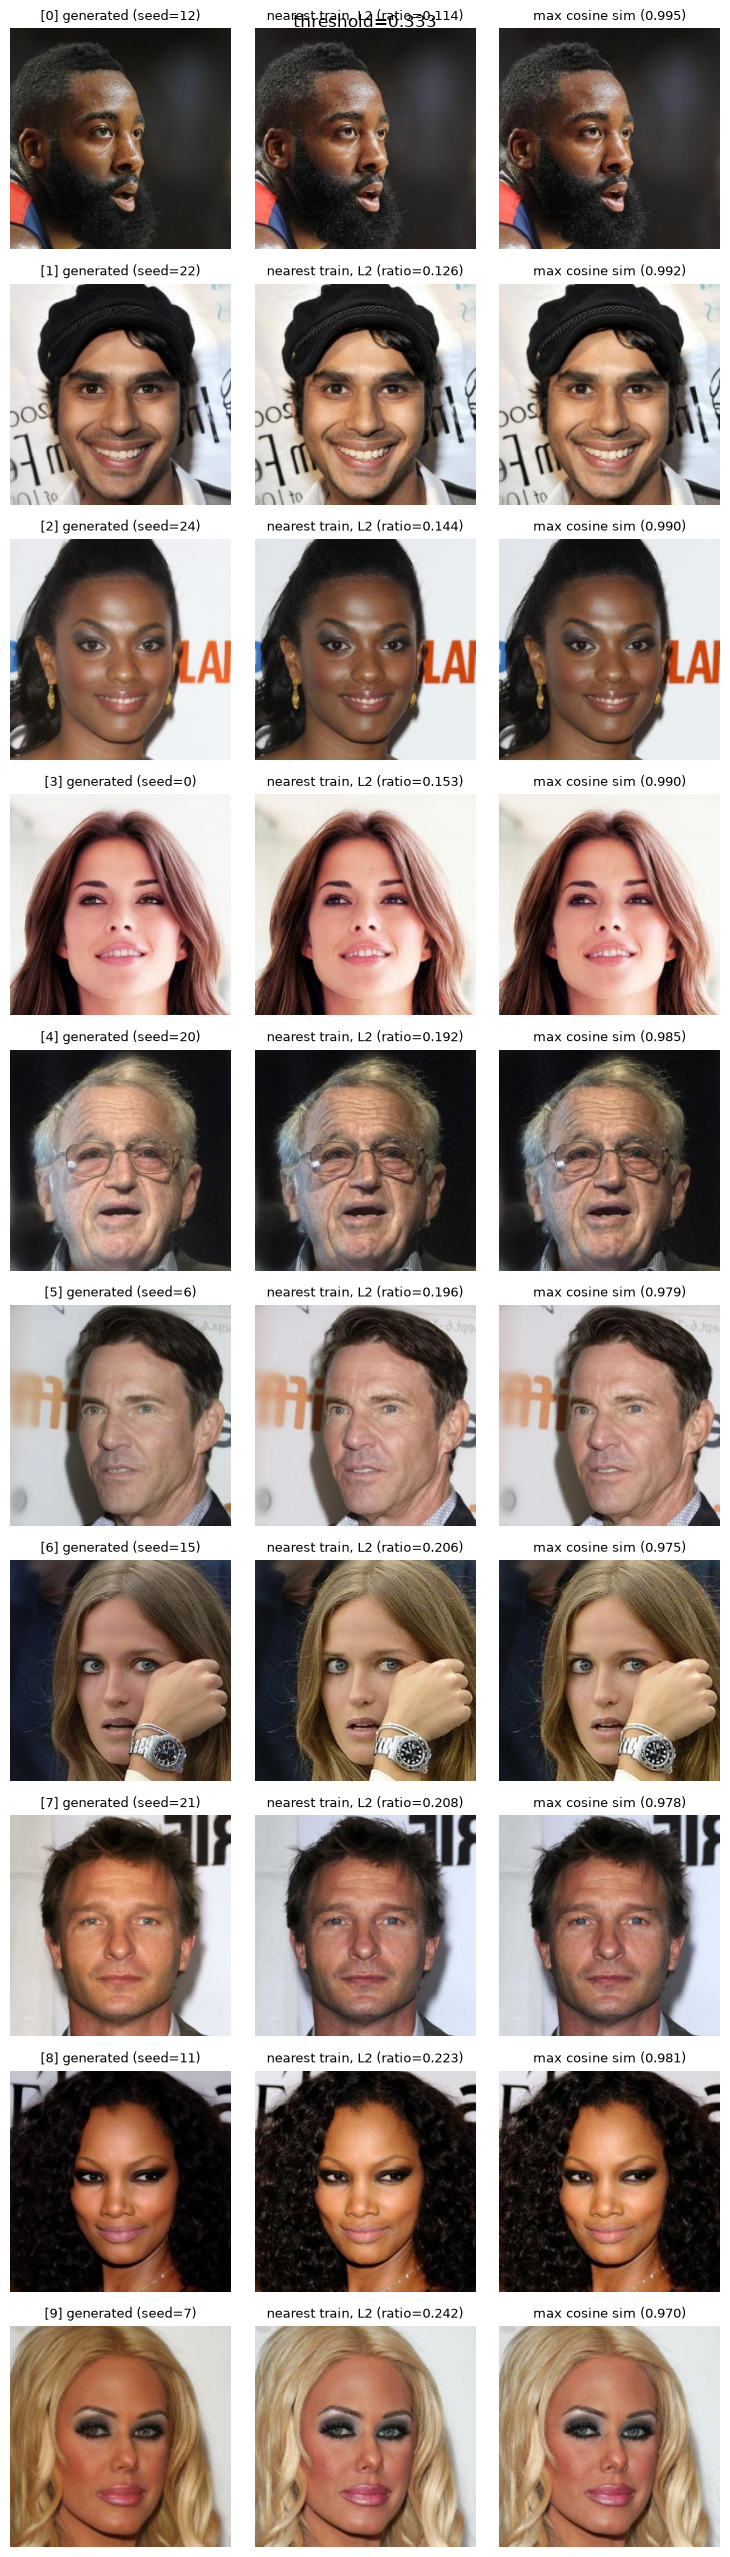

In [17]:
vae = AutoencoderKL.from_pretrained(config["vae_dir"]).to(device).eval()


def decode(z_single):
    z_single = unpack(z_single.to(device))  # accepts either packed [1,D] or already-4D latents
    with torch.no_grad():
        img = vae.decode(z_single / vae.config.scaling_factor).sample
    return img.clamp(-1, 1).cpu()


def load_nn(fname, mirrored):
    img = Image.open(os.path.join(config["train_images_dir"], fname)).convert("RGB")
    return img.transpose(Image.FLIP_LEFT_RIGHT) if mirrored else img


n_show = len(candidates)
fig, axes = plt.subplots(n_show, 3, figsize=(7.5, 2.6 * n_show), squeeze=False)
for row, c in enumerate(candidates):
    nn_file, nn_mirrored = ft_idx_to_file(int(ft_latent_idx[c["nn_idx"]]))
    cos_file, cos_mirrored = ft_idx_to_file(int(ft_latent_idx[c["cos_nn_idx"]]))
    gen_img = decode(c["z_single"])
    axes[row, 0].imshow(((gen_img[0] + 1) / 2).permute(1, 2, 0).numpy())
    axes[row, 0].set_title(f"[{row}] generated (seed={c['seed']})", fontsize=9)
    axes[row, 1].imshow(np.array(load_nn(nn_file, nn_mirrored)))
    axes[row, 1].set_title(f"nearest train, L2 (ratio={c['ratio']:.3f})", fontsize=9)
    axes[row, 2].imshow(np.array(load_nn(cos_file, cos_mirrored)))
    axes[row, 2].set_title(f"max cosine sim ({c['cos_sim']:.3f})", fontsize=9)
    for ax in axes[row]:
        ax.axis("off")
fig.suptitle(f"threshold={config['mem_ratio_threshold']:.3f}")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fr_candidates_vs_nn.png"), dpi=150)
plt.show()

## Wire up the generic interface

Rebuilt fresh per condition, reseeded, so every arm starts from the same `z_init`. `y_fn`
returns the EDM denoiser's own preconditioned output, already the clean-latent estimate.

In [18]:
def make_wiring(sigmas):
    def base_step(z_t, step_idx):
        s_cur, s_next = sigmas[step_idx - 1], sigmas[step_idx]
        x_t = unpack(z_t)
        d_cur = (x_t - edm_precond(x_t, s_cur.expand(1))) / s_cur
        x_next = x_t + (s_next - s_cur) * d_cur
        if s_next > 0:
            d_next = (x_next - edm_precond(x_next, s_next.expand(1))) / s_next
            x_next = x_t + (s_next - s_cur) * 0.5 * (d_cur + d_next)
        return pack(x_next)

    def y_fn(z_t):
        x_t = unpack(z_t)
        return pack(edm_precond(x_t, y_fn.s.expand(1)))

    def base_step_with_s(z_t, step_idx):
        y_fn.s = sigmas[step_idx - 1]
        return base_step(z_t, step_idx)

    def sigma2_fn():
        return (y_fn.s ** 2).expand(1)

    return y_fn, base_step_with_s, sigma2_fn


def z_init_from(seed, sigmas):
    generator = torch.Generator(device=device if device != "mps" else "cpu").manual_seed(seed)
    x = (torch.randn(1, 4, 32, 32, generator=generator).to(device)) * sigmas[0]
    return pack(x)

## Guidance energy -- ambient (latent space), no projector

In [19]:
def make_energy_fn(hp, sigma2_fn):
    def energy_fn(y):
        with torch.no_grad():
            neighbors, sq_d = basic_fr.ann_query(train_index, y, config["k_neighbors"])
        bf = basic_fr.beta_soft_for(sq_d, hp.get("q_target"))
        I, _, _ = basic_fr.fisher_rao_energy(y, neighbors, sigma2_fn(), beta_soft=bf)
        return I
    return energy_fn


def make_guidance_fn(hp, y_fn, sigma2_fn):
    return driver.make_autograd_guidance_fn(y_fn, make_energy_fn(hp, sigma2_fn), target_range=None)

## Run one condition

`run_condition(seed, hp, eta, window_hi, guided=True)`; `guided=False` runs the identical
wiring/`z_init` unguided, so arms are paired exactly.

In [20]:
def run_condition(seed, hp, eta, window_hi, guided=True):
    sigmas = make_sigmas(N_STEPS)
    y_fn, base_step_with_s, sigma2_fn = make_wiring(sigmas)
    z_init = z_init_from(seed, sigmas)

    if not guided:
        z = z_init
        with torch.no_grad():
            for step_idx in range(1, N_STEPS + 1):
                z = base_step_with_s(z, step_idx)
        z_final = z
        I_log = []
    else:
        z_final, I_log = driver.guided_reverse_loop(
            z_init, N_STEPS, base_step_with_s, make_guidance_fn(hp, y_fn, sigma2_fn),
            progress_lo=config["window_lo"], progress_hi=window_hi, ell=config["ell"],
            trust_region=eta)

    z_final = z_final.detach()
    stats = eval_memorization(unpack(z_final))
    cos_stats = eval_cosine_nn(unpack(z_final))
    return z_final.cpu(), I_log, {**stats, **cos_stats}


by_seed = {c["seed"]: c for c in candidates}
t0 = time.time()
_, _, stats_check = run_condition(SEEDS[0], {}, None, None, guided=False)
print(f"sanity check (seed={SEEDS[0]}): ratio={stats_check['ratio']:.3f} "
      f"({time.time() - t0:.1f}s)")
assert stats_check["nn_idx"] == by_seed[SEEDS[0]]["nn_idx"] and abs(stats_check["ratio"] - by_seed[SEEDS[0]]["ratio"]) < 1e-4, \
    "unguided run_condition should reproduce the seed search's sample_one bit-exactly"

sanity check (seed=12): ratio=0.114 (2.1s)


## Unguided Fisher-Rao energy `I(D_t(x))`, `q_max`, and `d1/d2` along the trajectory, per seed

Where the untempered energy rises and falls along each seed's own unguided trajectory, plus
`d1/d2` directly (more interpretable at only 200 atoms). Shaded band marks the guidance window.

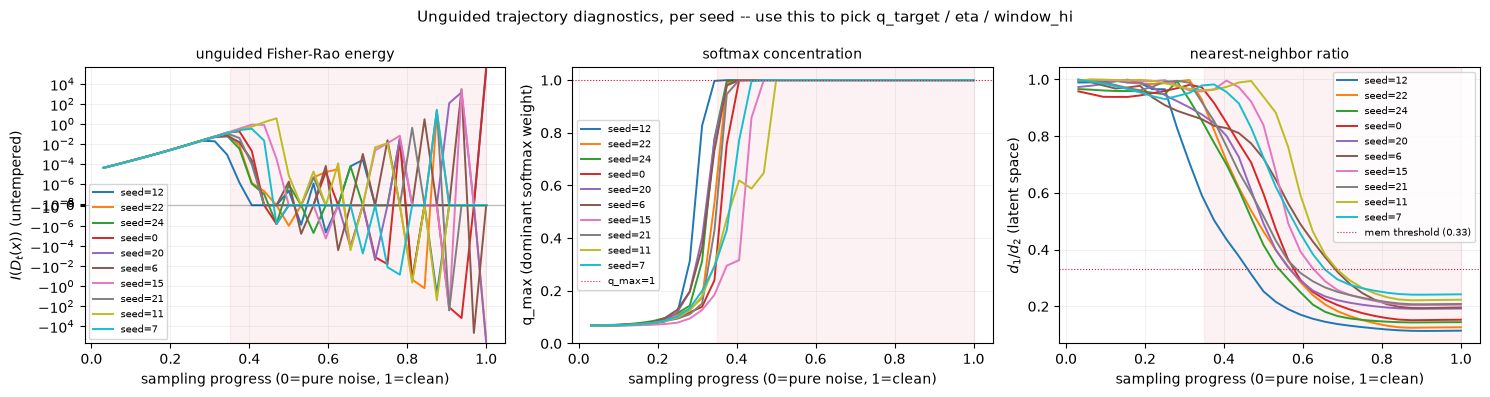

In [21]:
def unguided_trajectory(seed):
    sigmas = make_sigmas(N_STEPS)
    y_fn, base_step_with_s, sigma2_fn = make_wiring(sigmas)
    z = z_init_from(seed, sigmas)
    I_vals, q_max_vals, ratio_vals = [], [], []
    with torch.no_grad():
        for step_idx in range(1, N_STEPS + 1):
            y_fn.s = sigmas[step_idx - 1]
            y = y_fn(z)
            neighbors, sq_d = basic_fr.ann_query(train_index, y, config["k_neighbors"])
            I, q, _ = basic_fr.fisher_rao_energy(y, neighbors, sigma2_fn())
            I_vals.append(I.item())
            q_max_vals.append(q.max(-1).values.item())
            ratio_vals.append((sq_d[0, 0] / sq_d[0, 1]).sqrt().item())
            z = base_step_with_s(z, step_idx)
    progress = np.arange(1, N_STEPS + 1) / N_STEPS
    return {"seed": seed, "progress": progress, "I": np.array(I_vals),
            "q_max": np.array(q_max_vals), "ratio": np.array(ratio_vals)}


unguided_trajs = [unguided_trajectory(s) for s in SEEDS]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = plt.cm.tab10.colors
for ax in axes:
    ax.axvspan(config["window_lo"], as_list(config["window_hi"])[0], color="crimson", alpha=0.06,
               zorder=0)
    ax.set_xlabel("sampling progress (0=pure noise, 1=clean)")
    ax.grid(alpha=0.25, lw=0.5)

all_I = np.concatenate([tr["I"] for tr in unguided_trajs])
finite_I = all_I[np.isfinite(all_I) & (all_I != 0)]
linthresh = max(np.abs(finite_I).min(), 1e-12) if finite_I.size else 1e-6
for i, tr in enumerate(unguided_trajs):
    c = colors[i % len(colors)]
    axes[0].plot(tr["progress"], tr["I"], lw=1.4, color=c, label=f"seed={tr['seed']}")
    axes[1].plot(tr["progress"], tr["q_max"], lw=1.4, color=c, label=f"seed={tr['seed']}")
    axes[2].plot(tr["progress"], tr["ratio"], lw=1.4, color=c, label=f"seed={tr['seed']}")

axes[0].axhline(0, color="k", lw=0.5, alpha=0.3)
axes[0].set_yscale("symlog", linthresh=linthresh)
axes[0].set_ylabel(r"$I(D_t(x))$ (untempered)")
axes[0].set_title("unguided Fisher-Rao energy", fontsize=10)
axes[0].legend(fontsize=7)

axes[1].axhline(1.0, color="crimson", lw=0.8, ls=":", label="q_max=1")
axes[1].set_ylim(0, 1.05)
axes[1].set_ylabel("q_max (dominant softmax weight)")
axes[1].set_title("softmax concentration", fontsize=10)
axes[1].legend(fontsize=7)

axes[2].axhline(config["mem_ratio_threshold"], color="crimson", lw=0.8, ls=":",
                 label=f"mem threshold ({config['mem_ratio_threshold']:.2f})")
axes[2].set_ylabel(r"$d_1/d_2$ (latent space)")
axes[2].set_title("nearest-neighbor ratio", fontsize=10)
axes[2].legend(fontsize=7)

fig.suptitle("Unguided trajectory diagnostics, per seed -- use this to pick q_target / eta / window_hi", fontsize=11)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "unguided_energy_vs_progress.png"), dpi=150)
plt.show()

In [22]:
hp = {"q_target": as_list(config["q_target"])[0]}
eta = as_list(config["eta"])[0]
window_hi = as_list(config["window_hi"])[0]

results = []   # one {"seed", "z_baseline", "z_guided", "stats_baseline", "stats_guided", "I_log"} per seed
for seed in SEEDS:
    t0 = time.time()
    z_baseline, _, stats_baseline = run_condition(seed, {}, None, None, guided=False)
    z_guided, I_log, stats_guided = run_condition(seed, hp, eta, window_hi, guided=True)
    runtime_s = time.time() - t0
    results.append({"seed": seed, "z_baseline": z_baseline, "z_guided": z_guided,
                     "stats_baseline": stats_baseline, "stats_guided": stats_guided,
                     "I_log": I_log, "runtime_s": runtime_s})
    print(f"seed={seed}: unguided ratio={stats_baseline['ratio']:.3f} (memorized={stats_baseline['is_memorized']})  "
          f"-> guided ratio={stats_guided['ratio']:.3f} (memorized={stats_guided['is_memorized']})  "
          f"({runtime_s:.1f}s)")

n_broken = sum(r["stats_baseline"]["is_memorized"] and not r["stats_guided"]["is_memorized"] for r in results)
print(f"\nguidance broke the memorized match on {n_broken}/{len(results)} seeds "
      f"(hp={hp}, eta={eta}, window=({config['window_lo']}, {window_hi}))")

seed=12: unguided ratio=0.114 (memorized=True)  -> guided ratio=1.000 (memorized=False)  (5.4s)
seed=22: unguided ratio=0.126 (memorized=True)  -> guided ratio=1.000 (memorized=False)  (5.4s)
seed=24: unguided ratio=0.144 (memorized=True)  -> guided ratio=1.000 (memorized=False)  (5.4s)
seed=0: unguided ratio=0.153 (memorized=True)  -> guided ratio=0.999 (memorized=False)  (5.4s)
seed=20: unguided ratio=0.192 (memorized=True)  -> guided ratio=0.999 (memorized=False)  (5.4s)
seed=6: unguided ratio=0.196 (memorized=True)  -> guided ratio=1.000 (memorized=False)  (5.3s)
seed=15: unguided ratio=0.206 (memorized=True)  -> guided ratio=1.000 (memorized=False)  (5.9s)
seed=21: unguided ratio=0.208 (memorized=True)  -> guided ratio=0.999 (memorized=False)  (6.6s)
seed=11: unguided ratio=0.223 (memorized=True)  -> guided ratio=0.968 (memorized=False)  (5.8s)
seed=7: unguided ratio=0.242 (memorized=True)  -> guided ratio=0.999 (memorized=False)  (5.3s)

guidance broke the memorized match on 10/1

## Baseline vs. guided, decoded

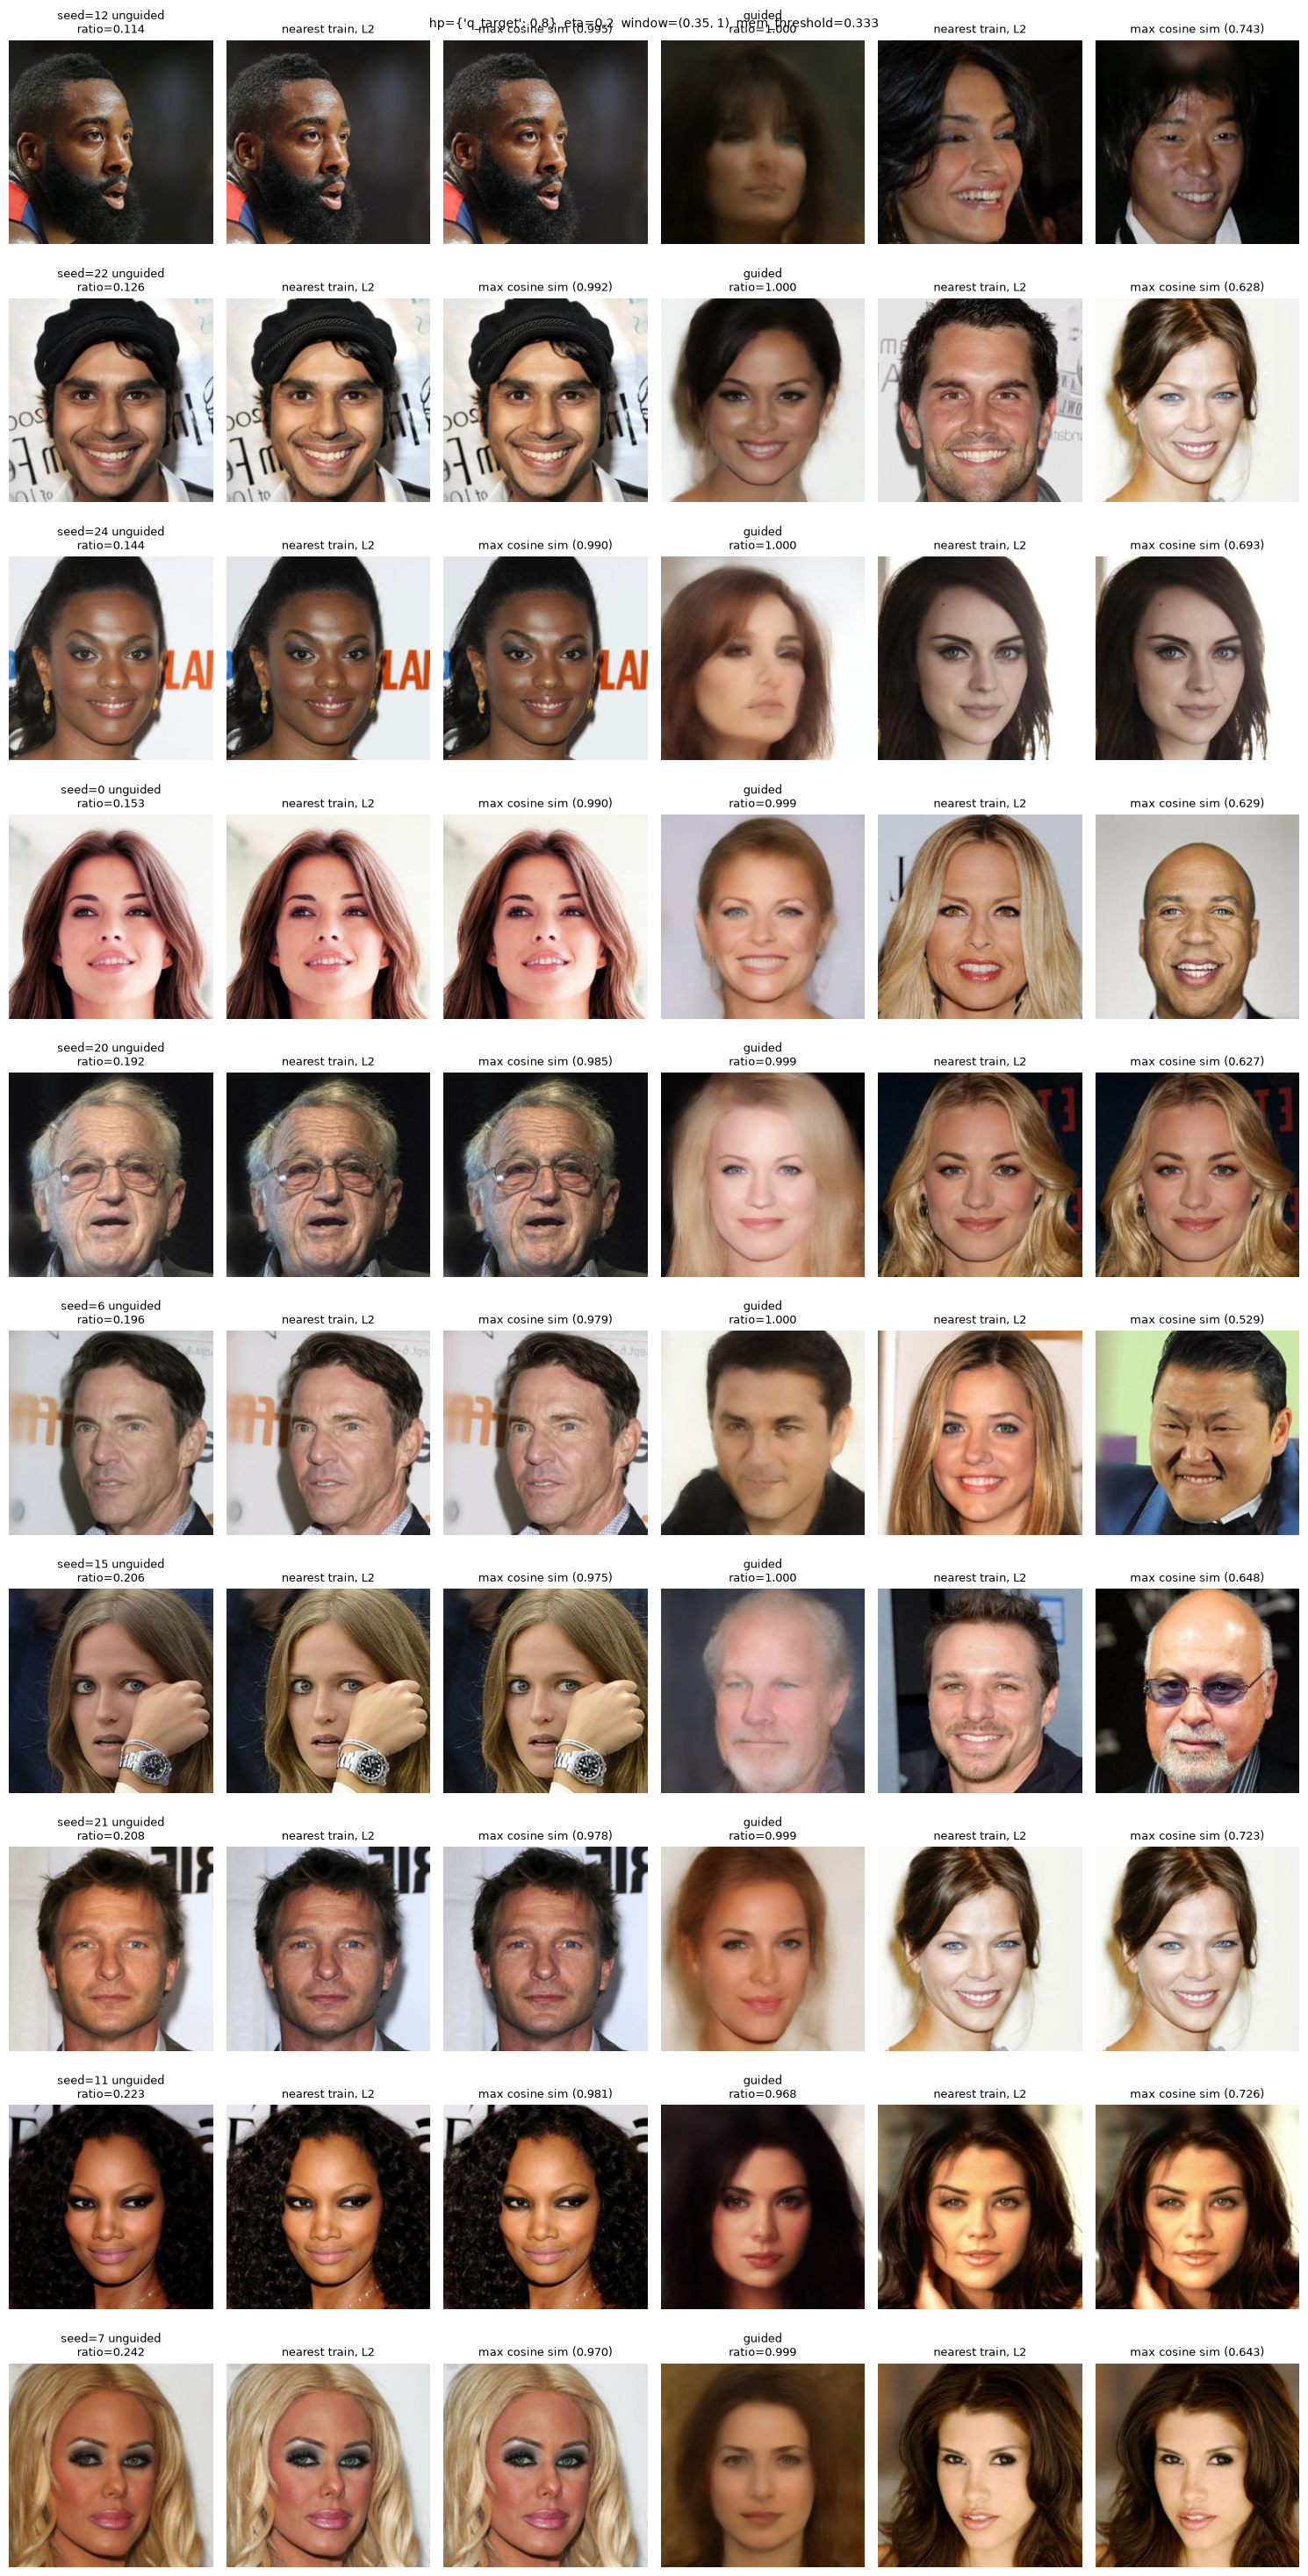

 seed  unguided_ratio  unguided_memorized  unguided_cos_sim  guided_ratio  guided_memorized  guided_cos_sim  broke_memorization  runtime_s
   12        0.114038                True          0.994628      0.999598             False        0.742894                True   5.442276
   22        0.126162                True          0.991654      0.999871             False        0.628298                True   5.375853
   24        0.144043                True          0.990038      0.999856             False        0.692879                True   5.350646
    0        0.152720                True          0.989830      0.999435             False        0.628671                True   5.392166
   20        0.192052                True          0.985219      0.999230             False        0.627060                True   5.423553
    6        0.195908                True          0.979234      0.999608             False        0.529270                True   5.317757
   15        0.205503      

In [23]:
n_rows = len(results)
fig, axes = plt.subplots(n_rows, 6, figsize=(15, 3.0 * n_rows), squeeze=False)
for row, r in enumerate(results):
    sb, sg = r["stats_baseline"], r["stats_guided"]
    img_baseline = decode(r["z_baseline"])
    img_guided = decode(r["z_guided"])
    nn_file_b, mirrored_b = ft_idx_to_file(int(ft_latent_idx[sb["nn_idx"]]))
    nn_file_g, mirrored_g = ft_idx_to_file(int(ft_latent_idx[sg["nn_idx"]]))
    cos_file_b, cos_mirrored_b = ft_idx_to_file(int(ft_latent_idx[sb["cos_nn_idx"]]))
    cos_file_g, cos_mirrored_g = ft_idx_to_file(int(ft_latent_idx[sg["cos_nn_idx"]]))

    axes[row, 0].imshow(((img_baseline[0] + 1) / 2).permute(1, 2, 0).numpy())
    axes[row, 0].set_title(f"seed={r['seed']} unguided\nratio={sb['ratio']:.3f}", fontsize=9)
    axes[row, 1].imshow(np.array(load_nn(nn_file_b, mirrored_b)))
    axes[row, 1].set_title("nearest train, L2", fontsize=9)
    axes[row, 2].imshow(np.array(load_nn(cos_file_b, cos_mirrored_b)))
    axes[row, 2].set_title(f"max cosine sim ({sb['cos_sim']:.3f})", fontsize=9)
    axes[row, 3].imshow(((img_guided[0] + 1) / 2).permute(1, 2, 0).numpy())
    axes[row, 3].set_title(f"guided\nratio={sg['ratio']:.3f}", fontsize=9)
    axes[row, 4].imshow(np.array(load_nn(nn_file_g, mirrored_g)))
    axes[row, 4].set_title("nearest train, L2", fontsize=9)
    axes[row, 5].imshow(np.array(load_nn(cos_file_g, cos_mirrored_g)))
    axes[row, 5].set_title(f"max cosine sim ({sg['cos_sim']:.3f})", fontsize=9)
    for ax in axes[row]:
        ax.axis("off")

fig.suptitle(f"hp={hp}  eta={eta}  window=({config['window_lo']}, {window_hi})"
             f"  mem_threshold={config['mem_ratio_threshold']:.3f}", fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "fr_guidance_baseline_vs_guided.png"), dpi=150)
plt.show()

import pandas as pd

summary_df = pd.DataFrame([{
    "seed": r["seed"],
    "unguided_ratio": r["stats_baseline"]["ratio"], "unguided_memorized": r["stats_baseline"]["is_memorized"],
    "unguided_cos_sim": r["stats_baseline"]["cos_sim"],
    "guided_ratio": r["stats_guided"]["ratio"], "guided_memorized": r["stats_guided"]["is_memorized"],
    "guided_cos_sim": r["stats_guided"]["cos_sim"],
    "broke_memorization": r["stats_baseline"]["is_memorized"] and not r["stats_guided"]["is_memorized"],
    "runtime_s": r["runtime_s"],
} for r in results])
summary_df.to_csv(os.path.join(OUT_DIR, "fr_guidance_summary.csv"), index=False)
print(summary_df.to_string(index=False))

## Save

In [24]:
torch.save({
    "seeds": SEEDS, "n_steps": N_STEPS, "config": config, "hp": hp, "eta": eta,
    "window": (config["window_lo"], window_hi),
    "results": results,
}, os.path.join(OUT_DIR, "fr_guidance_multi_seed_results.pt"))
print(f"saved to {OUT_DIR}/fr_guidance_multi_seed_results.pt and {OUT_DIR}/fr_guidance_summary.csv")

saved to checkpoints/fr_guidance_multi_seed_results.pt and checkpoints/fr_guidance_summary.csv
